# Example of Decision Tree using a mockup Customer Churn Data

In [57]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [51]:
# Download the mockup dataset from file customer_churn_data.csv
data = pd.read_csv('customer_churn_data.csv')
# Delete all nan records from data
data = data.dropna()

# create df dataframe from data
df = pd.DataFrame(data)

df


,age_of_account,days_since_last_login,orders_in_last_6_months,total_orders,total_spent,avg_order_value,churn_score
0,3,1,20,30.0,8450,281,0
1,4,3,10,15.0,3252,216,1
2,5,5,30,45.0,3729,83,1
3,5,9,40,60.0,5115,85,0
4,7,20,5,7.5,8743,1165,1
5,7,50,50,75.0,5833,78,0
6,10,75,30,45.0,3939,87,1
7,7,80,30,45.0,3443,76,1
8,8,85,10,15.0,9687,645,1
9,8,90,20,30.0,1349,45,1


In [52]:
# create X and Y, feature and target variable from df. The churn_score is the target variable
X = df.drop('churn_score', axis=1)
y = df['churn_score']


# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Accuracy with max_depth=1: 0.50


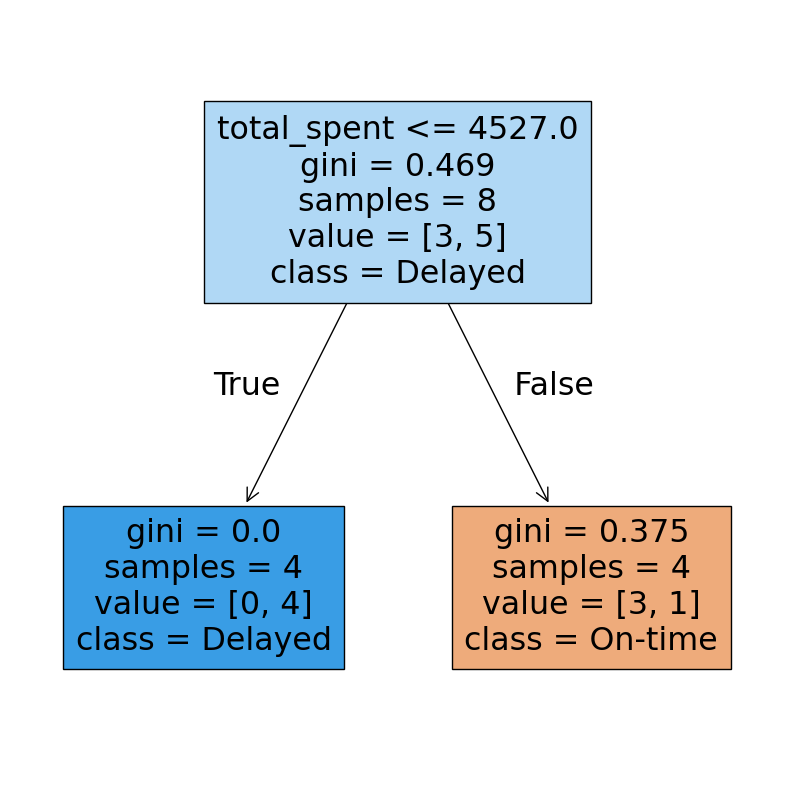

Accuracy with max_depth=10: 1.00


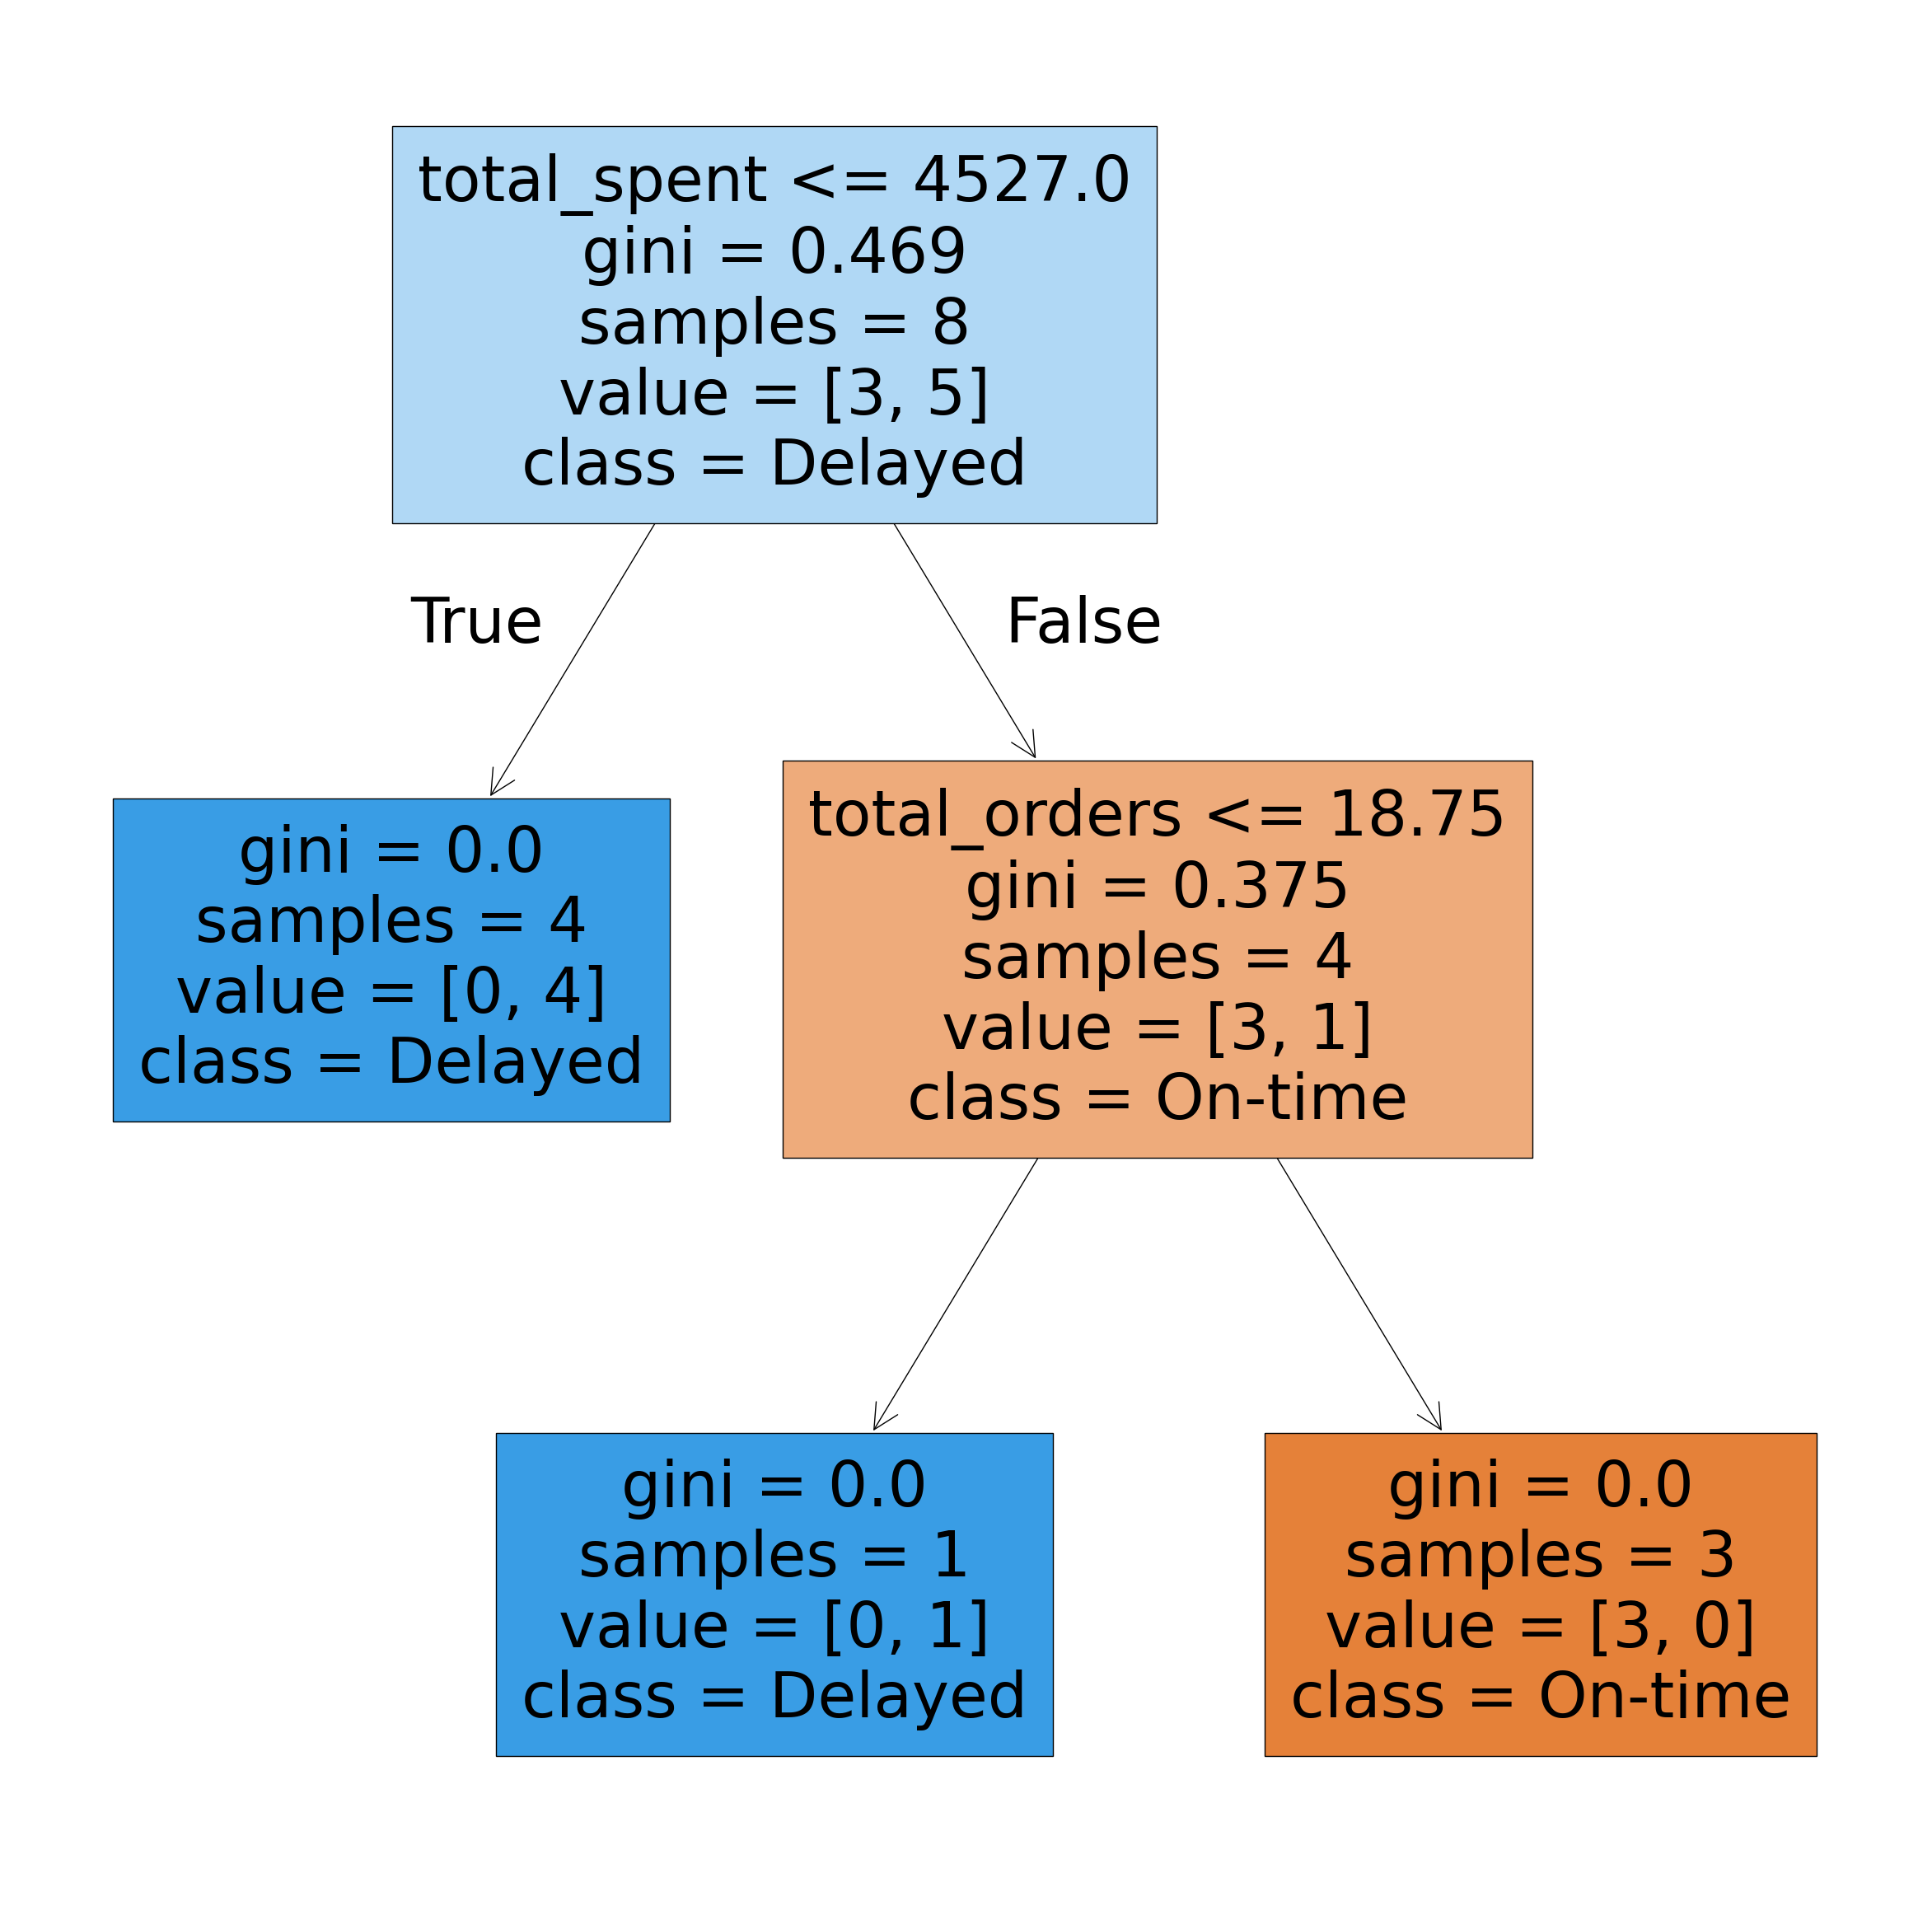

Accuracy with entropy criterion: 1.00


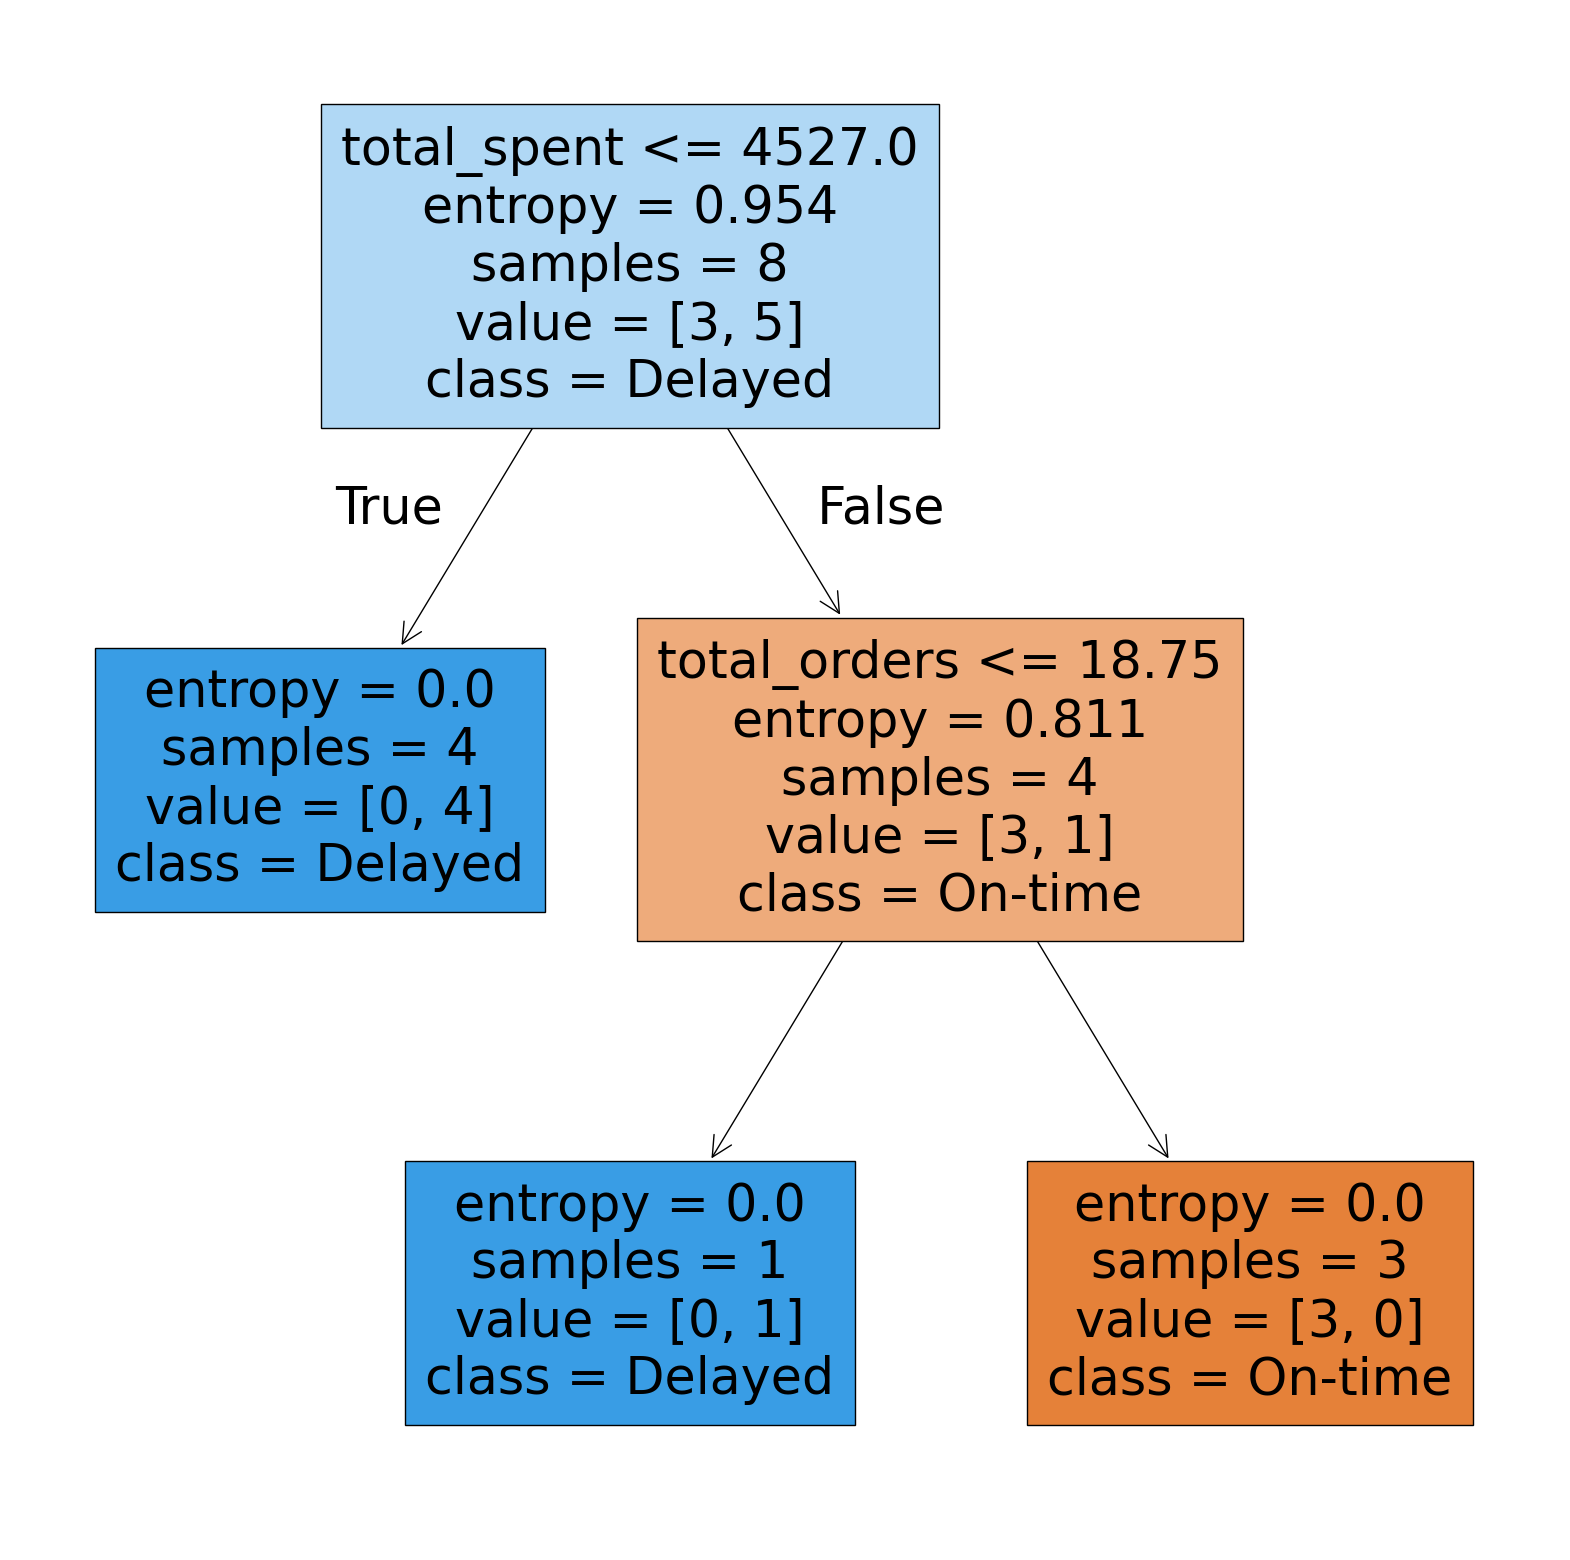

In [56]:
# Create a decision dree with max_depth=1 and visualize it. Show the accuracy of the model
model_depth_1 = DecisionTreeClassifier(max_depth=1, random_state=42)
model_depth_1.fit(X_train, y_train)
y_pred_depth_1 = model_depth_1.predict(X_test)
accuracy_depth_1 = accuracy_score(y_test, y_pred_depth_1)
print(f'Accuracy with max_depth=1: {accuracy_depth_1:.2f}')
plt.figure(figsize=(10,10))
plot_tree(model_depth_1, feature_names=X.columns, class_names=['On-time', 'Delayed'], filled=True)
plt.show()

# Create a decision dree with max_depth=10 and visualize it. Show the accuracy of the model
model_depth_10 = DecisionTreeClassifier(max_depth=10, random_state=42)
model_depth_10.fit(X_train, y_train)
y_pred_depth_10 = model_depth_10.predict(X_test)
accuracy_depth_10 = accuracy_score(y_test, y_pred_depth_10)
print(f'Accuracy with max_depth=10: {accuracy_depth_10:.2f}')
plt.figure(figsize=(30,30))
plot_tree(model_depth_10, feature_names=X.columns, class_names=['On-time', 'Delayed'], filled=True)
plt.show()

# Initialize and train the Decision Tree Classifier with entropy criterion
model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_entropy.fit(X_train, y_train)
y_pred_entropy = model_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
print(f'Accuracy with entropy criterion: {accuracy_entropy:.2f}')
plt.figure(figsize=(20,20))
plot_tree(model_entropy, feature_names=X.columns, class_names=['On-time', 'Delayed'], filled=True)
plt.show()

### We notice that the accuracy reduces when we reduce the depth, but increases as depth increases.
### We are using both Gini and Entropy mechanisms to showcase the use case.